**Marketing Insight For E-commerce company**

**Bussiness Context**

**One of the leading E-Commerce Company would like to get marketing insights from the data to define marketing strategies going forward. Also, expecting to build an analytical dashboard to monitor various KPI’s & business metrics.**

In [403]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

**Import The Dataset**

In [404]:
cust =pd.read_excel('CustomersData.xlsx')
dist =pd.read_csv('Discount_Coupon.csv')
market =pd.read_csv('Marketing_Spend.csv',parse_dates=['Date'])
sales =pd.read_csv('Online_Sales.csv',parse_dates=['Transaction_Date'])
tax =pd.read_excel('Tax_amount.xlsx')

**Data Preprocessing**

In [405]:
## Column name Cleaning / Standardization
sales.columns = sales.columns.str.strip().str.lower()
market.columns = market.columns.str.strip().str.lower()
tax.columns = tax.columns.str.strip().str.lower()
dist.columns = dist.columns.str.strip().str.lower()
cust.columns = cust.columns.str.strip().str.lower()

**Date Transformation**

In [406]:
sales['year'] = sales['transaction_date'].dt.year
sales['month'] = sales['transaction_date'].dt.month
sales['day'] = sales['transaction_date'].dt.day
sales['weekday'] = sales['transaction_date'].dt.day_name()
sales['week'] = sales['transaction_date'].dt.weekday

**Key Defination**
**Invoice Value:  Invoice Value =(( Quantity*Avg_price)*(1-Dicount_pct)*(1+GST))+Delivery_Charges
Average order value = Revenue / Transaction per customer **

In [407]:
dist['month'] = pd.to_datetime(
    dist['month'],
    format='%b',      # Jan, Feb, Mar...
    errors='coerce'
).dt.month

In [408]:
dist_map = dist.set_index(['month','product_category'])['discount_pct'].to_dict()

In [409]:
def map_discount(row):
    return dist_map.get((row['month'], row['product_category']), 0)

In [410]:
sales['discount_pct'] = sales.apply(map_discount,axis=1)/100

In [411]:
def map_discount(row):
  return dist_map.get((row['month'],row['product_category']),0)

In [412]:
sales['discount_pct'] = sales.apply(map_discount,axis = 1)/100

In [413]:
gst_map = tax.set_index('product_category')['gst'].to_dict()

In [414]:
sales['gst'] = sales['product_category'].map(gst_map)

In [415]:
sales['base_amount'] = sales['quantity']*sales['avg_price']
sales['after_discount']=sales['base_amount']*(1-sales['discount_pct'])
sales['after_tax'] = sales['after_discount']*(1+sales['gst'])
sales['invoice'] = sales['after_tax'] + sales['delivery_charges']

In [416]:
data = cust.merge(sales,on='customerid',how='right')

In [417]:
data = data.merge(market.rename(columns={'date':'transaction_date'}),
                  on = 'transaction_date',
                  how='left')

In [418]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customerid           52924 non-null  int64         
 1   gender               52924 non-null  object        
 2   location             52924 non-null  object        
 3   tenure_months        52924 non-null  int64         
 4   transaction_id       52924 non-null  int64         
 5   transaction_date     52924 non-null  datetime64[ns]
 6   product_sku          52924 non-null  object        
 7   product_description  52924 non-null  object        
 8   product_category     52924 non-null  object        
 9   quantity             52924 non-null  int64         
 10  avg_price            52924 non-null  float64       
 11  delivery_charges     52924 non-null  float64       
 12  coupon_status        52924 non-null  object        
 13  year                 52924 non-

In [419]:
## EDA

**Explolaroty Data Analysis[EDA]**

In [420]:
## Understanding how many customers acquired every month

In [421]:
first_purchase = data.groupby('customerid')['transaction_date'].min().reset_index()
first_purchase['acquired_month'] = first_purchase['transaction_date'].dt.month
monthly_aquired = first_purchase.groupby('acquired_month')['customerid'].count().reset_index()
monthly_aquired.columns = ['Month', 'Customers_Acquired']
print(monthly_aquired)

    Month  Customers_Acquired
0       1                 215
1       2                  96
2       3                 177
3       4                 163
4       5                 112
5       6                 137
6       7                  94
7       8                 135
8       9                  78
9      10                  87
10     11                  68
11     12                 106


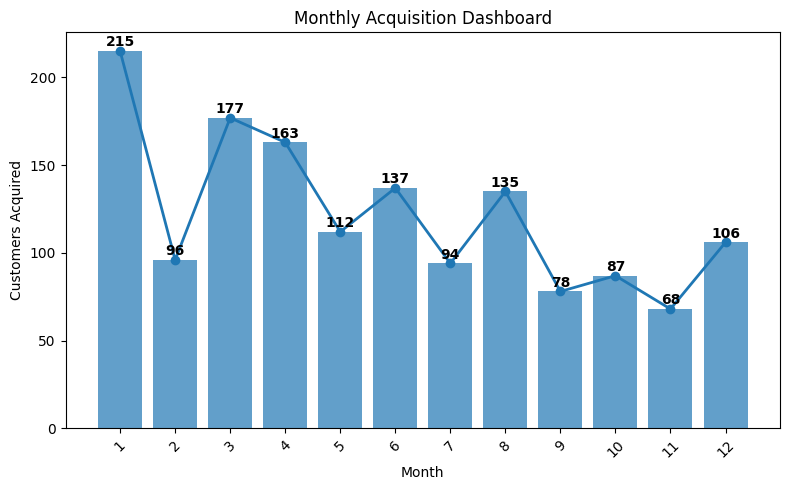

In [422]:
fig, ax = plt.subplots(figsize=(8,5))

# Bar chart
ax.bar(
    monthly_aquired['Month'].astype(str),
    monthly_aquired['Customers_Acquired'],
    alpha=0.7
)

# Line chart
ax.plot(
    monthly_aquired['Month'].astype(str),
    monthly_aquired['Customers_Acquired'],
    marker='o',
    linewidth=2
)

# Add values on line dots
for i, value in enumerate(monthly_aquired['Customers_Acquired']):
    ax.text(
        i, value + 1, str(value),   # +1 moves text slightly above dot
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(rotation=45)
plt.title("Monthly Acquisition Dashboard")
plt.xlabel("Month")
plt.ylabel("Customers Acquired")
plt.tight_layout()
plt.show()

`***Customer acquisition every month means counting unique new customers whose first transaction happened in that month.***`

In [423]:
## Understand the retention of customers on month on month basis

In [424]:
## Get Unique Customers per Month
monthly_custome = data.groupby('month')['customerid'].apply(set).reset_index()
monthly_custome

,month,customerid
0,1,"{17920, 14849, 15363, 17924, 17925, 17412, 174..."
1,2,"{13831, 15880, 16905, 16393, 15373, 13838, 158..."
2,3,"{17920, 16898, 14850, 13319, 12808, 14344, 158..."
3,4,"{16385, 16898, 17411, 13319, 15881, 16907, 133..."
4,5,"{15361, 16899, 16393, 15881, 13324, 17404, 179..."
5,6,"{14849, 17412, 13829, 13317, 15366, 14344, 153..."
6,7,"{13313, 17924, 13319, 15373, 13329, 15379, 174..."
7,8,"{15370, 16395, 13842, 14867, 17428, 16923, 128..."
8,9,"{16904, 17418, 17419, 16395, 16912, 16401, 153..."
9,10,"{14849, 16387, 14341, 13837, 15373, 12829, 138..."


In [425]:
## calculate Month -on Month Retention
retention=[]
for i in range(len(monthly_custome)-1):
  current_month = monthly_custome.iloc[i]['month']
  next_month = monthly_custome.iloc[i+1]['month']

  current_user = monthly_custome.iloc[i]['customerid']
  next_user = monthly_custome.iloc[i+1]['customerid']

  retained = current_user.intersection(next_user)
  retention_rate = len(retained) / len(current_user) * 100

  retention.append({
      'Month': str(current_month),
      'Next_Month': str(next_month),
      'Customers': len(current_user),
      'Retained_customer': len(retained),
      'Retaintion%': round(retention_rate,2)
  })

retention_df = pd.DataFrame(retention)
retention_df

,Month,Next_Month,Customers,Retained_customer,Retaintion%
0,1,2,215,13,6.05
1,2,3,109,11,10.09
2,3,4,208,24,11.54
3,4,5,224,25,11.16
4,5,6,200,37,18.50
5,6,7,259,58,22.39
6,7,8,236,65,27.54
7,8,9,300,44,14.67
8,9,10,193,29,15.03
9,10,11,210,31,14.76


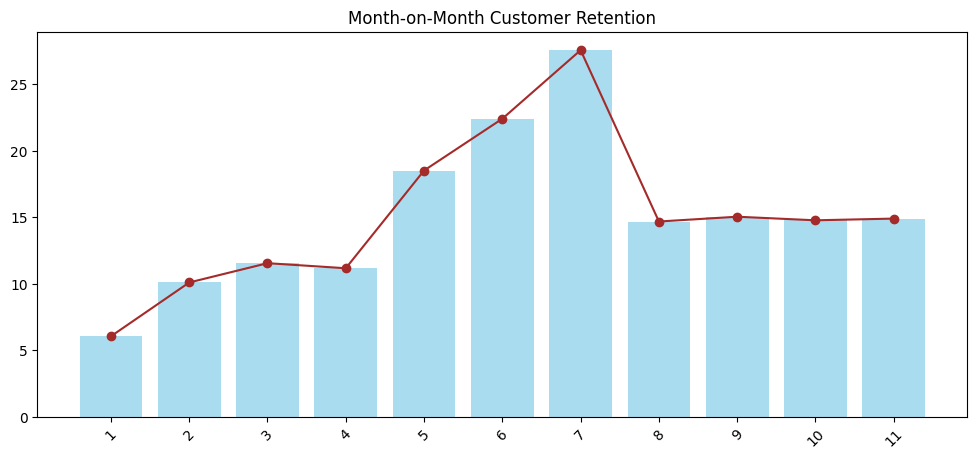

In [426]:
fig, ax = plt.subplots(figsize=(12,5))

ax.bar(retention_df['Month'], retention_df['Retaintion%'], alpha=0.7,color = 'skyblue')
ax.plot(retention_df['Month'], retention_df['Retaintion%'], marker='o',color='brown')

plt.title("Month-on-Month Customer Retention")
plt.xticks(rotation=45)
plt.show()


**`“I analyzed customer retention month-on-month by tracking repeat customers from one month to the next and measuring retention percentage.”`**

# *How the revenues from existing/new customers on month on month basis *

In [427]:
df = data.copy()

In [428]:
df['YearMonth'] = df['transaction_date'].dt.to_period('M')

df['FirstPurchaseMonth'] = df.groupby('customerid')['transaction_date'] \
                             .transform('min').dt.to_period('M')


In [429]:
# Customer Type
df['CustomerType'] = df.apply(
    lambda x: 'New' if x['YearMonth'] == x['FirstPurchaseMonth'] else 'Existing',
    axis=1
)

In [430]:
df['CustomerType'].unique()

array(['New', 'Existing'], dtype=object)

In [431]:
# Monthly revenue split
monthly_revenue = df.groupby(['YearMonth', 'CustomerType'])['after_tax'] \
                    .sum().reset_index()

# Pivot
rev_pivot = monthly_revenue.pivot(index='YearMonth',
                                  columns='CustomerType',
                                  values='after_tax').fillna(0)

rev_pivot

CustomerType,Existing,New
YearMonth,,
2019-01,0.00000,404640.73705
2019-02,35012.22768,243667.73252
2019-03,43628.85852,232376.40531
2019-04,170132.78296,236384.67227
2019-05,99640.35388,177519.77668
2019-06,101226.62571,151090.12360
2019-07,224241.22578,151017.18783
2019-08,185842.43804,171218.55900
2019-09,166007.31823,114115.61815


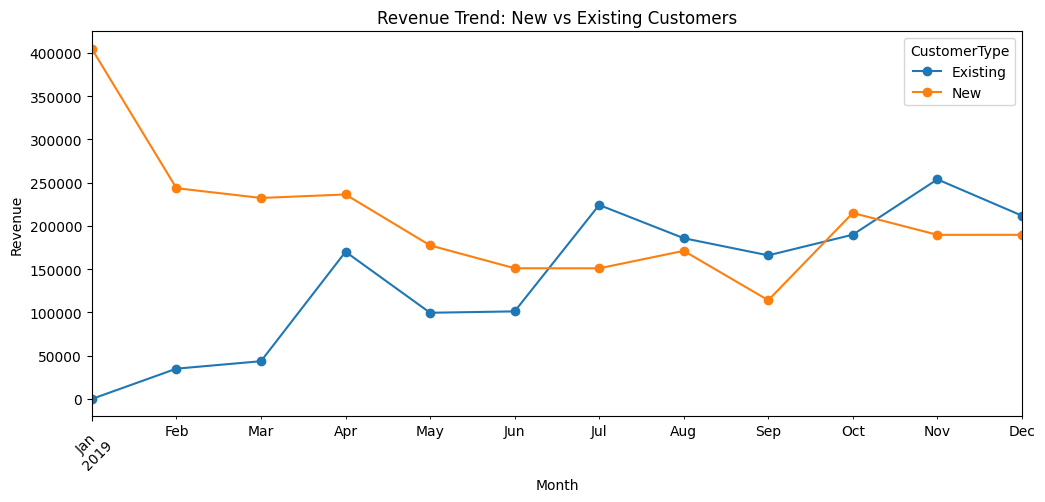

In [432]:
rev_pivot.plot(figsize=(12,5), marker='o')

plt.title("Revenue Trend: New vs Existing Customers")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**`“I segmented monthly revenue into new and existing customers using first purchase month logic to evaluate acquisition and retention contribution.”`**

**How the discounts playing role in the revenues? **

In [433]:
## Discount Bucket
# Discount bucket
bins = [-1, 0, 5, 10, 20, 30, 50, 100]
labels = ['0%', '1-5%', '6-10%', '11-20%', '21-30%', '31-50%', '50%+']

df['discount_bucket'] = pd.cut(df['discount_pct'],bins=bins,labels=labels)

In [434]:
## Revenue by discount Bucket
dist_rev = df.groupby('discount_bucket')['after_tax'].sum().reset_index()
dist_rev

,discount_bucket,after_tax
0,0%,3.060412e+04
1,1-5%,4.127272e+06
2,6-10%,0.000000e+00
3,11-20%,0.000000e+00
4,21-30%,0.000000e+00
5,31-50%,0.000000e+00
6,50%+,0.000000e+00


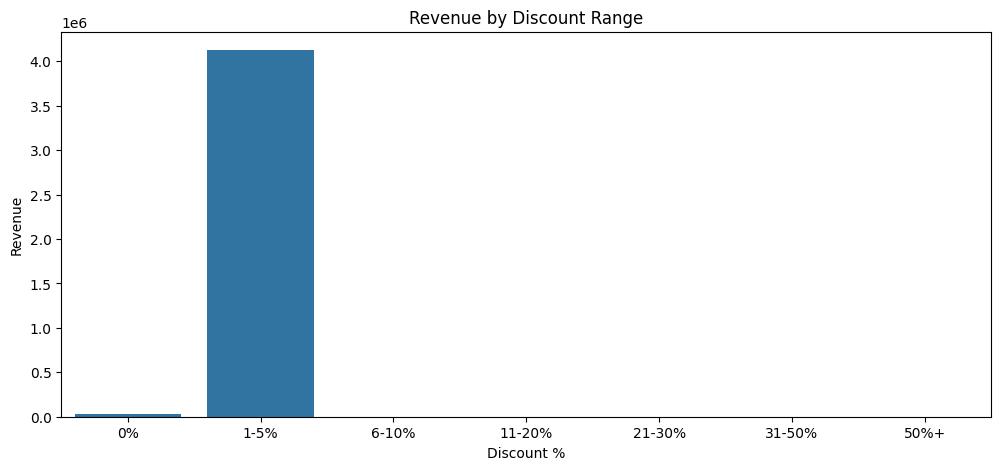

In [435]:

plt.figure(figsize=(12,5))
sns.barplot(data=dist_rev,x='discount_bucket',y='after_tax')
plt.title("Revenue by Discount Range")
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.show()

In [436]:
df['discount_pct']

,discount_pct
0,0.1
1,0.1
2,0.1
3,0.1
4,0.1
...,...
52919,0.3
52920,0.3
52921,0.3
52922,0.3


In [437]:
## Check Order Quantity
qty_discount = df.groupby('discount_bucket')['quantity'].sum()
qty_discount

,quantity
discount_bucket,
0%,1666
1-5%,236367
6-10%,0
11-20%,0
21-30%,0
31-50%,0
50%+,0


In [438]:
# Month on Month Discount Vs Revenue
monthly = df.groupby('month').agg({
    'discount_pct':'mean',
    'after_tax':'sum'
}).reset_index()

monthly

,month,discount_pct,after_tax
0,1,0.099016,404640.73705
1,2,0.197625,278679.96020
2,3,0.296134,276005.26383
3,4,0.098747,406517.45523
4,5,0.197550,277160.13056
5,6,0.297567,252316.74931
6,7,0.098953,375258.41361
7,8,0.198764,357060.99704
8,9,0.298951,280122.93638
9,10,0.099736,404875.58255


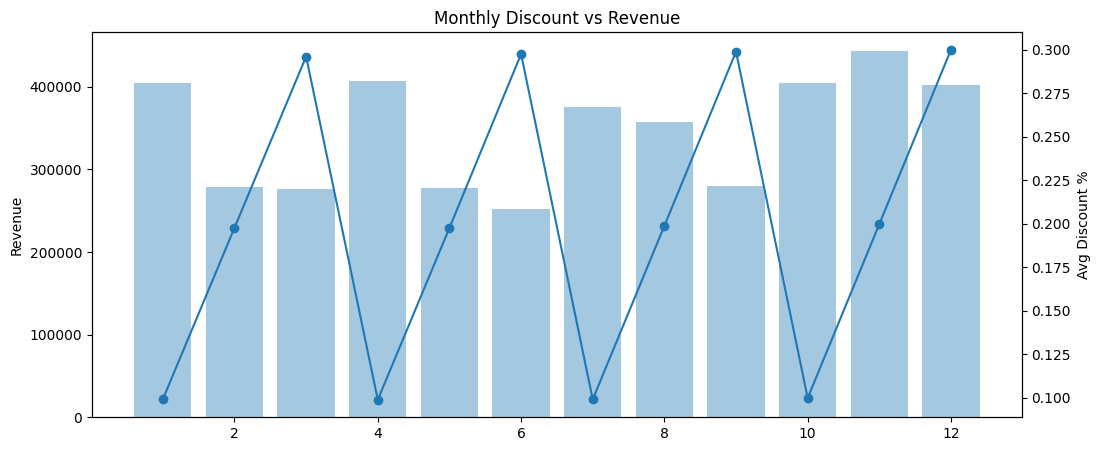

In [439]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.bar(monthly['month'], monthly['after_tax'], alpha=0.4)
ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['discount_pct'], marker='o')
ax2.set_ylabel("Avg Discount %")

plt.title("Monthly Discount vs Revenue")
plt.show()

**`I analyzed discount buckets against revenue and found the optimal discount range that maximizes sales without over-discounting.`**

In [440]:
## Analyse KPI’s like Revenue, number of orders, average order value, number of
## customers (existing/new), quantity, by category, by month, by week, by day etc…

In [441]:
## Master KPI Table
kpi = pd.DataFrame({
    'Revenue':[df['after_tax'].sum()],
    'Orders':[df['invoice'].nunique()],
    'Customer':[df['customerid'].nunique()],
    'Quantity':[df['quantity'].sum()]
}).reset_index()
kpi['AOV'] = kpi['Revenue']/kpi['Orders']
kpi

,index,Revenue,Orders,Customer,Quantity,AOV
0,0,4.157876e+06,10951,1468,238033,379.680074


In [442]:
## KPI by Month
monthly_kpi = df.groupby('YearMonth').agg(
    Revenue=('after_tax','sum'),
    Orders=('invoice','nunique'),
    Customers=('customerid','nunique'),
    Quantity=('quantity','sum')
).reset_index()
monthly_kpi['AOV']  = monthly_kpi['Revenue']/monthly_kpi['Orders']
monthly_kpi

,YearMonth,Revenue,Orders,Customers,Quantity,AOV
0,2019-01,404640.73705,910,215,20140,444.660151
1,2019-02,278679.96020,919,109,16575,303.242612
2,2019-03,276005.26383,1244,208,20787,221.869183
3,2019-04,406517.45523,1311,224,25277,310.081964
4,2019-05,277160.13056,1207,200,18715,229.627283
5,2019-06,252316.74931,1040,259,21619,242.612259
6,2019-07,375258.41361,1322,236,22898,283.856591
7,2019-08,357060.99704,1415,300,27457,252.339927
8,2019-09,280122.93638,1148,193,19353,244.009526
9,2019-10,404875.58255,1067,210,17425,379.452280


In [443]:
## KPI by Week
weekly_kpi = df.groupby('week').agg(
    Revenue=('after_tax','sum'),
    Orders=('invoice','nunique'),
    Customers=('customerid','nunique'),
    Quantity=('quantity','sum')
).reset_index()
weekly_kpi

,week,Revenue,Orders,Customers,Quantity
0,0,320885.56330,1581,258,11983
1,1,352315.68063,1617,274,11317
2,2,734149.74402,3153,433,39797
3,3,758084.73865,3304,445,44482
4,4,775147.69068,3443,474,52433
5,5,601672.88471,3096,400,37965
6,6,615620.18728,3079,390,40056


In [444]:
## KPI by Day
daily_kpi = df.groupby('day').agg(
    Revenue=('after_tax','sum'),
    Orders=('invoice','nunique'),
    Customers=('customerid','nunique'),
    Quantity=('quantity','sum')
).reset_index()
daily_kpi

,day,Revenue,Orders,Customers,Quantity
0,1,127381.20329,886,100,7178
1,2,129170.02676,826,92,7612
2,3,125485.84001,914,89,6545
3,4,121449.73632,861,108,6947
4,5,170406.02488,913,107,13399
5,6,138935.60047,972,98,8132
6,7,136960.42238,1016,97,8178
7,8,119017.61558,787,87,8028
8,9,125594.50422,919,80,7332
9,10,132611.60876,842,85,7801


In [445]:
# KPI by Category
category_kpi = df.groupby('product_category').agg(
    Revenue=('after_tax','sum'),
    Orders=('invoice','nunique'),
    Quantity=('quantity','sum'),
    Customers=('customerid','nunique')
).reset_index().sort_values(by='Revenue',ascending=False)

category_kpi['AOV'] = category_kpi['Revenue'] / category_kpi['Orders']
category_kpi

,product_category,Revenue,Orders,Quantity,Customers,AOV
16,Nest-USA,2.251675e+06,366,21430,1260,6152.118795
2,Apparel,5.585860e+05,3021,32438,1323,184.901025
14,Nest,4.238942e+05,173,2837,516,2450.255395
18,Office,2.455522e+05,2999,88383,1103,81.878020
6,Drinkware,1.901396e+05,1593,30501,919,119.359430
4,Bags,1.432080e+05,867,15273,728,165.176486
17,Notebooks & Journals,9.355898e+04,462,9556,383,202.508614
12,Lifestyle,7.132280e+04,1112,24881,817,64.139210
15,Nest-Canada,6.264280e+04,50,469,205,1252.856044
10,Headgear,4.599065e+04,259,3533,425,177.570089


In [446]:
## Existing Vs New Customer
cust_type = df.groupby('CustomerType').agg(
    Revenue=('after_tax','sum'),
    Customers=('customerid','nunique'),
    Orders=('invoice','nunique')
).reset_index()
cust_type

,CustomerType,Revenue,Customers,Orders
0,Existing,1.681385e+06,580,5455
1,New,2.476491e+06,1468,7818


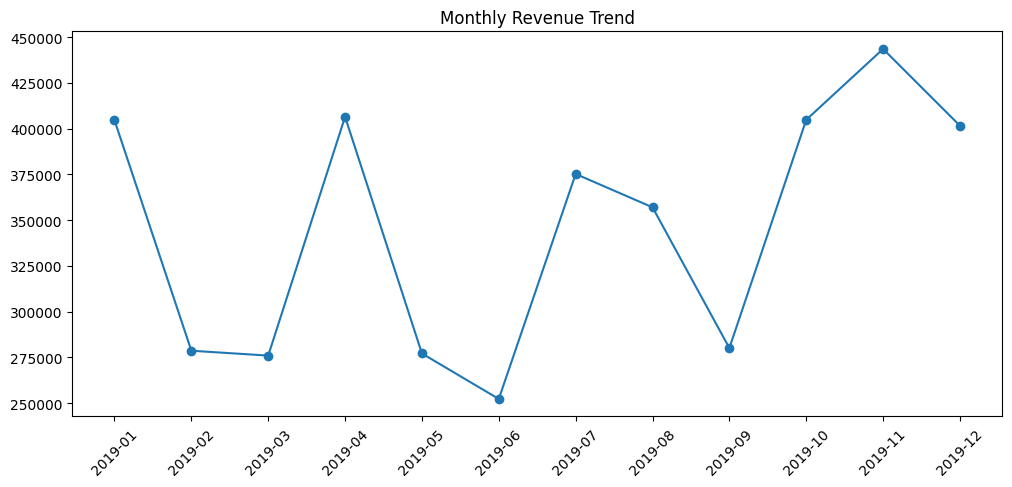

In [447]:
## Monthly Revenue Trend
plt.figure(figsize=(12,5))
plt.plot(monthly_kpi['YearMonth'].astype(str),
         monthly_kpi['Revenue'],
         marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

<Axes: xlabel='product_category'>

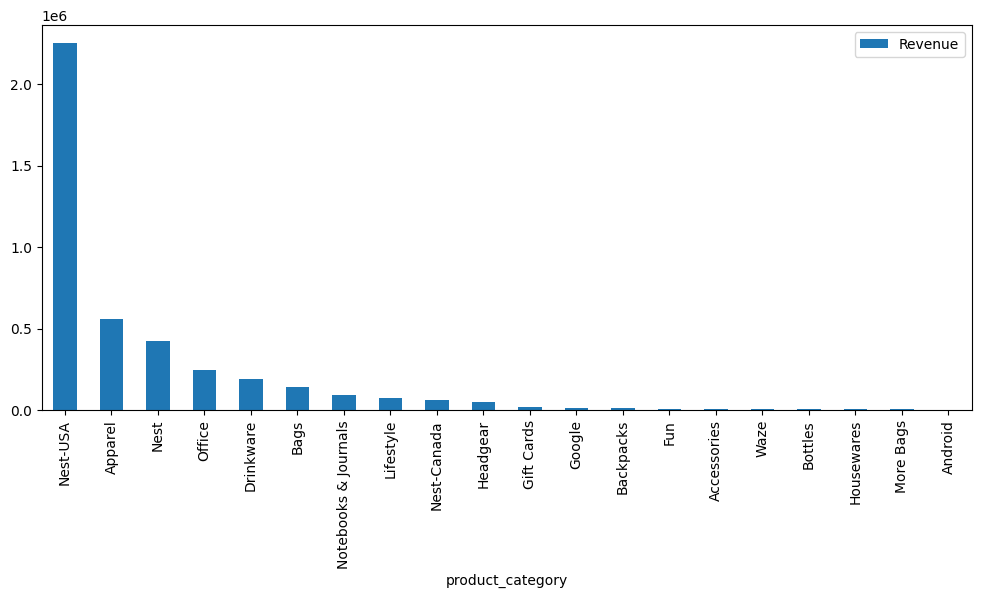

In [448]:
category_kpi.sort_values('Revenue', ascending=False)\
.plot(kind='bar', x='product_category', y='Revenue', figsize=(12,5))

**`I built KPI dashboards analyzing revenue, orders, AOV, quantity, and customer mix by month, week, day, and category to identify business growth drivers.`**

**Understand the trends/seasonality of sales by category, location, month etc… **

In [449]:
## Monthly Sales Trend
monthly_sales = df.groupby('month')['after_tax'].sum().reset_index(name='total_sales')
monthly_sales

,month,total_sales
0,1,404640.73705
1,2,278679.96020
2,3,276005.26383
3,4,406517.45523
4,5,277160.13056
5,6,252316.74931
6,7,375258.41361
7,8,357060.99704
8,9,280122.93638
9,10,404875.58255


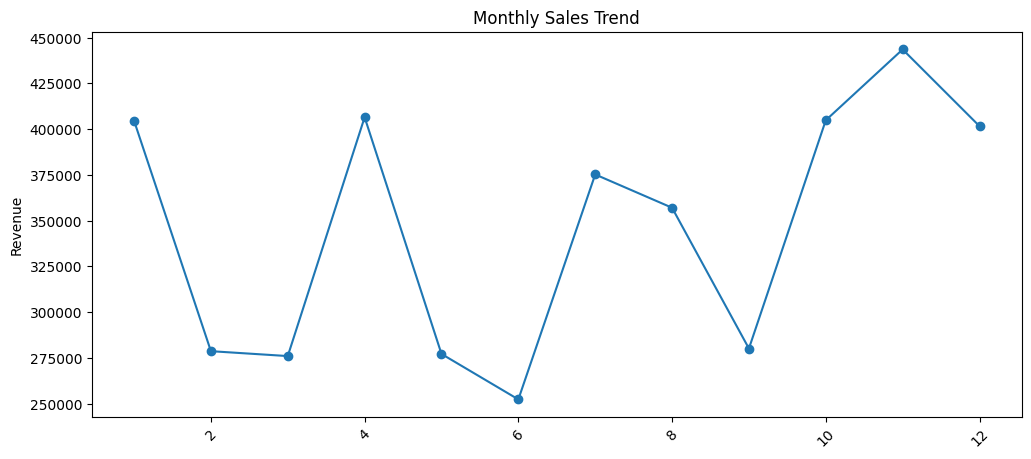

In [450]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales['month'],
         monthly_sales['total_sales'],
         marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

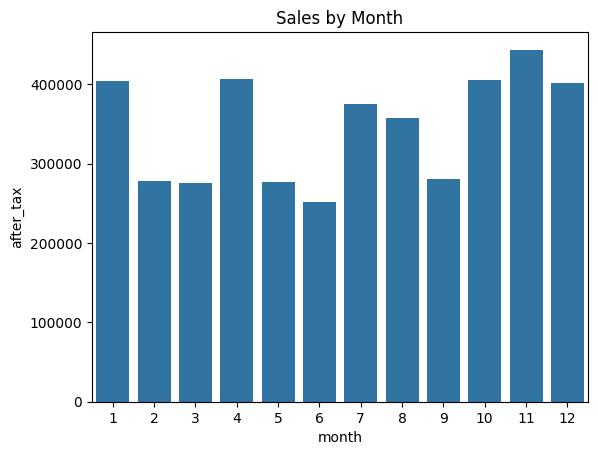

In [451]:
## Seasionality by Month
monthly_season = df.groupby('month')['after_tax'].sum().reset_index()
sns.barplot(data=monthly_season, x='month', y='after_tax')
plt.title("Sales by Month")
plt.show()

In [452]:
## Category Trend Over Time
cat_month = df.groupby(['month','product_category'])['after_tax'].sum().reset_index()
cat_month

,month,product_category,after_tax
0,1,Accessories,51.05430
1,1,Android,73.49760
2,1,Apparel,40675.52394
3,1,Backpacks,295.00900
4,1,Bags,11579.65506
...,...,...,...
202,12,Nest-Canada,4074.29330
203,12,Nest-USA,215746.39240
204,12,Notebooks & Journals,709.53960
205,12,Office,14187.68120


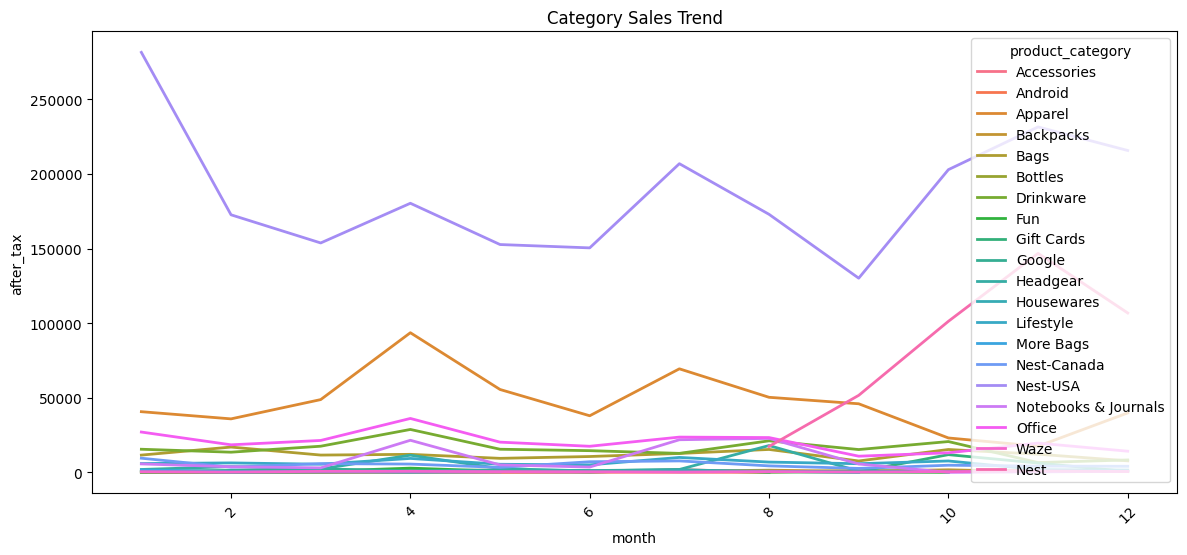

In [453]:
plt.figure(figsize=(14,6))

sns.lineplot(data=cat_month,
             x='month',
             y='after_tax',
             hue='product_category',linewidth=2)

plt.xticks(rotation=45)
plt.title("Category Sales Trend")
plt.show()

In [454]:
## Location Sales Trend
loc_sales = df.groupby(['location','month'])['after_tax'].sum().reset_index().sort_values(by=['month','after_tax'],ascending=[True,False])
loc_sales

,location,month,after_tax
0,California,1,150804.35229
12,Chicago,1,109997.13098
36,New York,1,78626.01837
48,Washington DC,1,33695.91413
24,New Jersey,1,31517.32128
13,Chicago,2,96958.89960
1,California,2,80259.15944
37,New York,2,40079.03684
49,Washington DC,2,34304.00392
25,New Jersey,2,27078.86040


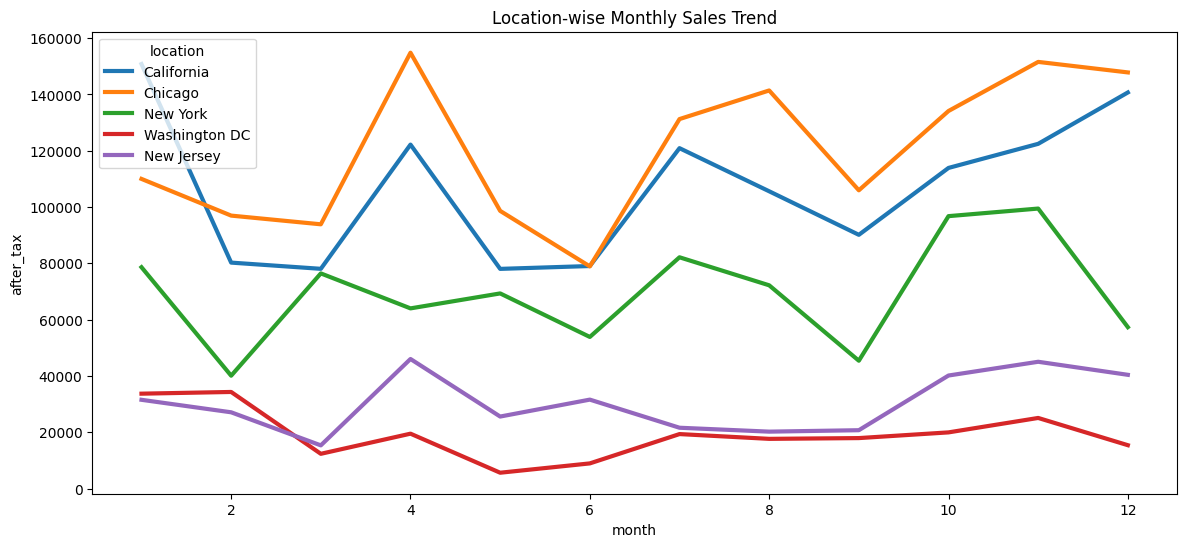

In [455]:
plt.figure(figsize=(14,6))

sns.lineplot(data=loc_sales,
             x='month',
             y='after_tax',
             hue='location',linewidth=3)

plt.title("Location-wise Monthly Sales Trend")
plt.show()

In [456]:
## Seasionlity
heat = df.pivot_table(
    values='after_tax',
    index='product_category',
    columns='month',
    aggfunc='sum'
)

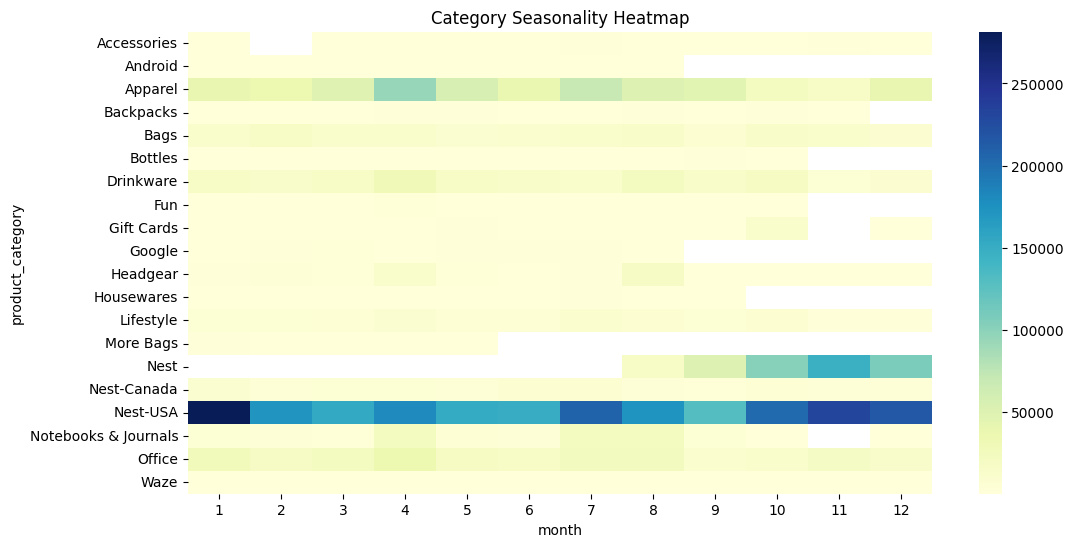

In [457]:
plt.figure(figsize=(12,6))
sns.heatmap(heat, cmap='YlGnBu', annot=False)

plt.title("Category Seasonality Heatmap")
plt.show()

**`“I analyzed sales trends and seasonality across categories, locations, and months to identify recurring demand patterns and growth opportunities.”`**

In [458]:
## KPI by Week Day
weekday_kpi = df.groupby('weekday').agg(
    Orders=('invoice','nunique'),
    Sales=('after_tax','sum')
).reset_index()

weekday_kpi

,weekday,Orders,Sales
0,Friday,3443,775147.69068
1,Monday,1581,320885.56330
2,Saturday,3096,601672.88471
3,Sunday,3079,615620.18728
4,Thursday,3304,758084.73865
5,Tuesday,1617,352315.68063
6,Wednesday,3153,734149.74402


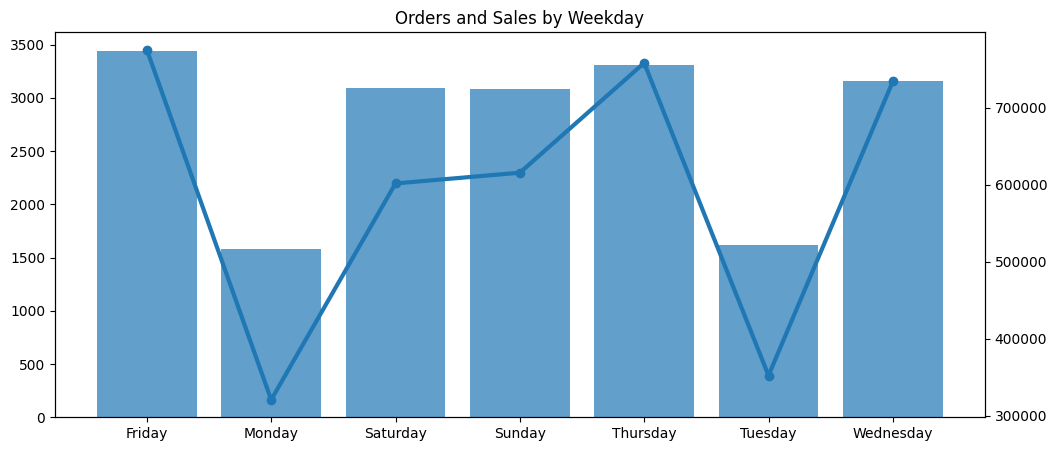

In [459]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.bar(weekday_kpi['weekday'],
        weekday_kpi['Orders'],
        alpha=0.7)

ax2 = ax1.twinx()

ax2.plot(weekday_kpi['weekday'],
         weekday_kpi['Sales'],
         marker='o',
         linewidth=3)

plt.title("Orders and Sales by Weekday")
plt.xticks(rotation=45)
plt.show()

In [460]:
## Day Of Month
day_kpi = df.groupby('day').agg(
    Orders=('invoice','nunique'),
    Sales=('after_tax','sum')
).reset_index()

day_kpi

,day,Orders,Sales
0,1,886,127381.20329
1,2,826,129170.02676
2,3,914,125485.84001
3,4,861,121449.73632
4,5,913,170406.02488
5,6,972,138935.60047
6,7,1016,136960.42238
7,8,787,119017.61558
8,9,919,125594.50422
9,10,842,132611.60876


**`“I analyzed orders and revenue by weekday and day-of-month to identify peak shopping days and optimize promotions/staffing`**

**How marketing spend is impacting on revenue**

In [461]:
## Total Marketing Spend
df['total_spend'] = df['online_spend']+df['offline_spend']

In [462]:
## Monthly Impact
monthly = df.groupby('month').agg(
    Revenue=('after_tax','sum'),
    OnlineSpend=('online_spend','sum'),
    OfflineSpend=('offline_spend','sum'),
    TotalSpend=('total_spend','sum')
).reset_index()

monthly

,month,Revenue,OnlineSpend,OfflineSpend,TotalSpend
0,1,404640.73705,7686875.17,12365900,20052775.17
1,2,278679.96020,6360136.05,9481400,15841536.05
2,3,276005.26383,6965280.31,10488500,17453780.31
3,4,406517.45523,8196922.13,13459000,21655922.13
4,5,277160.13056,7574021.02,9951500,17525521.02
5,6,252316.74931,7436403.73,11189000,18625403.73
6,7,375258.41361,9055934.41,11563000,20618934.41
7,8,357060.99704,11551233.77,16834500,28385733.77
8,9,280122.93638,7371126.34,11886500,19257626.34
9,10,404875.58255,7813772.39,12722500,20536272.39


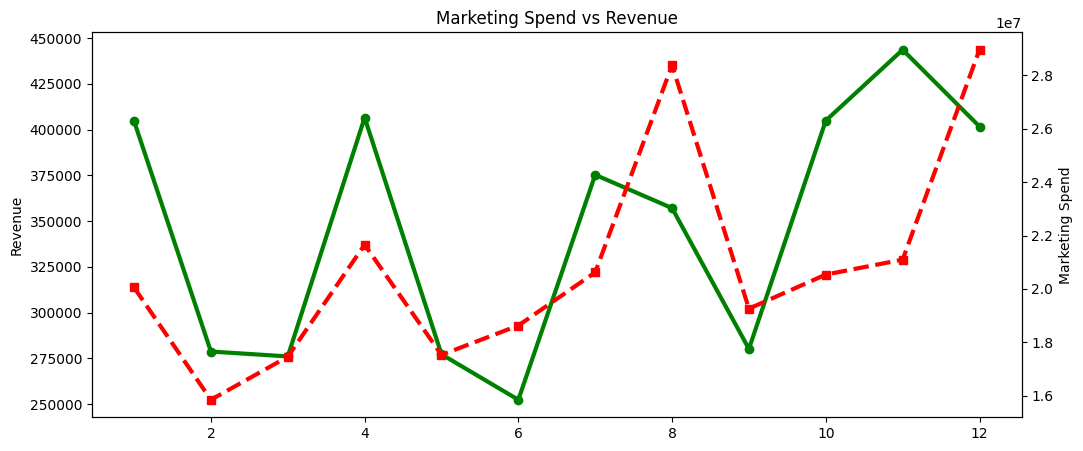

In [463]:
fig, ax1 = plt.subplots(figsize=(12,5))

# Revenue Line
ax1.plot(monthly['month'],
         monthly['Revenue'],
         marker='o',
         linewidth=3,
         label='Revenue',color = 'green')

ax1.set_ylabel("Revenue")

# Marketing Spend Line
ax2 = ax1.twinx()

ax2.plot(monthly['month'],
         monthly['TotalSpend'],
         marker='s',
         linewidth=3,
         linestyle='--',
         label='Marketing Spend',color = 'red')

ax2.set_ylabel("Marketing Spend")

plt.title("Marketing Spend vs Revenue")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='month'>

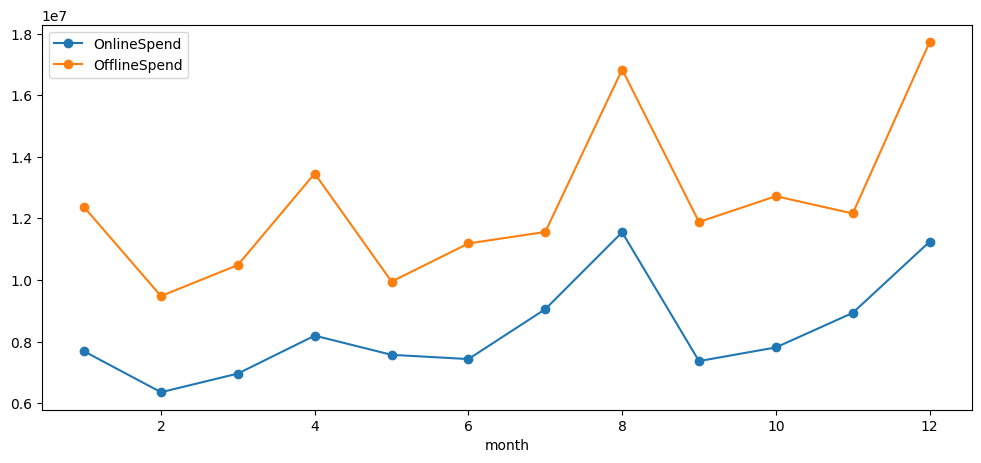

In [464]:
## Channel Comparision
channel = monthly[['month','OnlineSpend','OfflineSpend']]
channel.plot(x='month',
             figsize=(12,5),
             marker='o')

In [465]:
## Correlation check
monthly[['Revenue','TotalSpend']].corr()

,Revenue,TotalSpend
Revenue,1.000000,0.544226
TotalSpend,0.544226,1.000000


Interpretation
Correlation = 0.544

This indicates a moderate positive relationship between marketing spend and revenue.

```

```



In [466]:
## ROI(Return On Investment)

In [467]:
monthly['ROI'] = (monthly['Revenue'] / monthly['TotalSpend'])*100
monthly[['month','ROI']]

,month,ROI
0,1,2.017879
1,2,1.759173
2,3,1.581349
3,4,1.877165
4,5,1.581466
5,6,1.354691
6,7,1.819970
7,8,1.257889
8,9,1.454608
9,10,1.971514


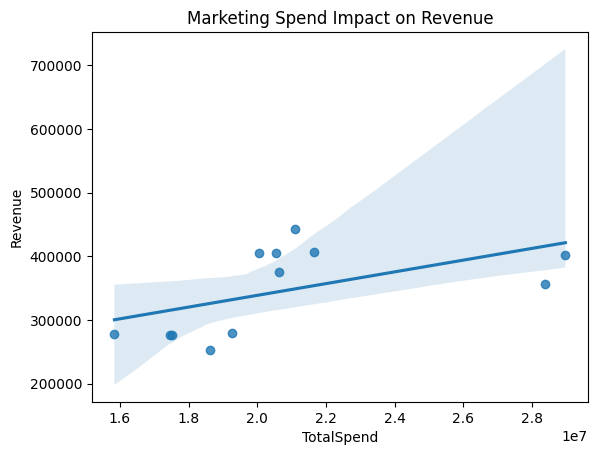

In [468]:
sns.regplot(data=monthly,
            x='TotalSpend',
            y='Revenue')

plt.title("Marketing Spend Impact on Revenue")
plt.show()

`I evaluated marketing effectiveness by comparing online/offline spend with monthly revenue and calculating ROI and correlation.”
I created a regression plot and found a moderate positive relationship between marketing spend and revenue. However, variability suggests other business drivers also influence sales`




**Which product was appeared in the transactions?**

In [469]:
## Products Appearing Most in Transactions
top_products = df.groupby('product_description').agg(
    Transactions=('invoice', 'nunique')
).reset_index().sort_values(
    by='Transactions',
    ascending=False
)

top_products.head(10)

,product_description,Transactions
101,Google 22 oz Water Bottle,358
212,Google Sunglasses,321
140,Google Laptop and Cell Phone Stickers,288
192,Google Metallic Notebook Set,252
301,Maze Pen,247
340,Sport Bag,235
90,Foam Can and Bottle Cooler,206
359,Windup Android,193
91,Four Color Retractable Pen,192
367,YouTube Custom Decals,191


In [470]:
df['product_description'].value_counts().head(10)


,count
product_description,
Nest Learning Thermostat 3rd Gen-USA - Stainless Steel,3511
Nest Cam Outdoor Security Camera - USA,3328
Nest Cam Indoor Security Camera - USA,3230
Google Sunglasses,1523
Nest Protect Smoke + CO White Battery Alarm-USA,1361
Nest Learning Thermostat 3rd Gen-USA - White,1089
Nest Protect Smoke + CO White Wired Alarm-USA,1065
Google 22 oz Water Bottle,902
Nest Thermostat E - USA,844


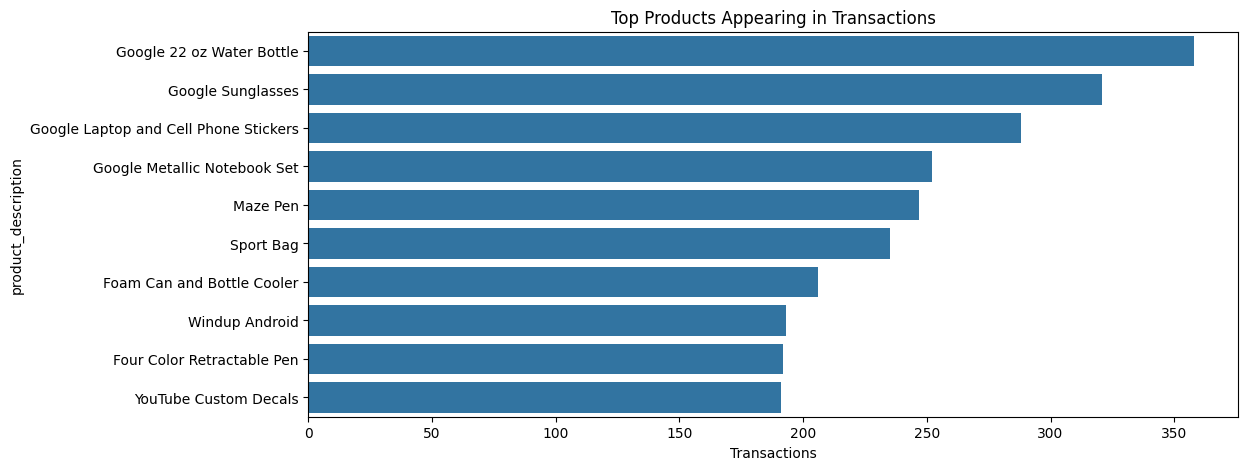

In [471]:
top10 = top_products.head(10)

plt.figure(figsize=(12,5))

sns.barplot(data=top10,
            x='Transactions',
            y='product_description')

plt.title("Top Products Appearing in Transactions")
plt.show()


In [472]:
## Unique Product Appeared
df['product_description'].nunique()

404

In [473]:
## Revenue by Instead of Frequency
df.groupby('product_description')['after_tax'].sum().reset_index(name='Revenue').sort_values(by='Revenue',ascending=False)

,product_description,Revenue
316,Nest Learning Thermostat 3rd Gen-USA - Stainle...,608814.26210
312,Nest Cam Outdoor Security Camera - USA,554652.48080
310,Nest Cam Indoor Security Camera - USA,467235.75470
321,Nest Protect Smoke + CO White Battery Alarm-USA,189243.65240
323,Nest Protect Smoke + CO White Wired Alarm-USA,188039.65510
...,...,...
215,Google Tee Red,44.43054
242,Google Women's Colorblock Tee White,23.11974
129,Google Infant Short Sleeve Tee Green,20.06354
68,Android Women's Short Sleeve Tri-blend Badge T...,12.54694


**`I analyzed product appearance in transactions using transaction frequency and identified top products driving customer purchases`**

**Which product was purchased mostly based on the quantity?**

In [474]:
top_qty = df.groupby('product_category')['quantity'].sum().reset_index().sort_values(by = 'quantity',ascending=False)
top_qty.head(10)

,product_category,quantity
18,Office,88383
2,Apparel,32438
6,Drinkware,30501
12,Lifestyle,24881
16,Nest-USA,21430
4,Bags,15273
17,Notebooks & Journals,9556
10,Headgear,3533
14,Nest,2837
11,Housewares,2484


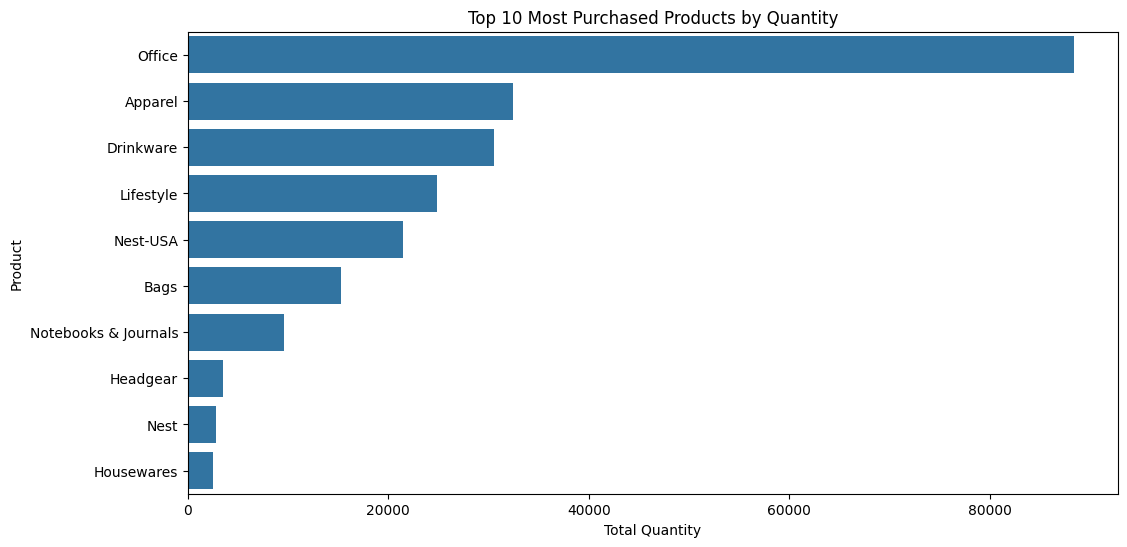

In [475]:
top10 = top_qty.head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=top10,
            x='quantity',
            y='product_category')

plt.title("Top 10 Most Purchased Products by Quantity")
plt.xlabel("Total Quantity")
plt.ylabel("Product")
plt.show()

**`I identified the most purchased products by aggregating quantity sold at product level and ranking the highest movers`**

**Performing Customer Segmentation**

# Heuristic (Value based, RFM) – Divide the customers into Premium, Gold, Silver,
# Standard customers and define strategy on the same.  

1. Heuristic / Value Based Segmentation
2. RFM Segmentation

Then classify into:

Premium
Gold
Silver
Standard

In [476]:
## PART 1 — Heuristic (Value Based)

In [477]:
## Segment by total revenue generated by customer
cust_value = df.groupby('customerid').agg(
    Revenue = ('after_tax','sum'),
    Orders = ('transaction_id','nunique'),
    Quantity = ('quantity','sum')
).reset_index()
cust_value

,customerid,Revenue,Orders,Quantity
0,12346,24.98174,1,3
1,12347,11425.15580,31,342
2,12348,1304.77620,8,209
3,12350,1055.83394,11,21
4,12356,1115.96086,13,56
...,...,...,...,...
1463,18259,538.07980,3,46
1464,18260,2014.82033,19,141
1465,18269,104.16092,2,10
1466,18277,295.02000,1,2


In [478]:
## Create Segment by Revenue Quartiles
bins = [0, 5000, 15000, 50000, cust_value['Revenue'].max()]
labels = ['Standard','Silver','Gold','Premium']

cust_value['Segment'] = pd.cut(
    cust_value['Revenue'],
    bins=bins,
    labels=labels
)

In [479]:
cust_value['Segment'].value_counts()

,count
Segment,
Standard,1234
Silver,210
Gold,22
Premium,2


**RFM Segmentation**

RFM =
*   Recency = Last purchase days ago
*   Frequency = Number of orders
*   Monetary = Total spend


In [480]:
snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customerid').agg({
    'transaction_date': lambda x: (snapshot_date - x.max()).days,
    'transaction_id':'nunique',
    'after_tax':'sum'
}).reset_index()
rfm.columns = ['customerid','Recency','Frequency','Monetary']

In [481]:
rfm

,customerid,Recency,Frequency,Monetary
0,12346,108,1,24.98174
1,12347,60,31,11425.15580
2,12348,74,8,1304.77620
3,12350,18,11,1055.83394
4,12356,108,13,1115.96086
...,...,...,...,...
1463,18259,271,3,538.07980
1464,18260,88,19,2014.82033
1465,18269,195,2,104.16092
1466,18277,70,1,295.02000


In [482]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

In [483]:
rfm

,customerid,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,108,1,24.98174,3,1,1,5
1,12347,60,31,11425.15580,4,5,5,14
2,12348,74,8,1304.77620,4,2,3,9
3,12350,18,11,1055.83394,5,3,2,10
4,12356,108,13,1115.96086,3,3,3,9
...,...,...,...,...,...,...,...,...
1463,18259,271,3,538.07980,1,1,2,4
1464,18260,88,19,2014.82033,4,4,3,11
1465,18269,195,2,104.16092,2,1,1,4
1466,18277,70,1,295.02000,4,1,1,6


In [484]:
def segment_map(score):
    if score >= 12:
        return "Premium"
    elif score >= 9:
        return "Gold"
    elif score >= 6:
        return "Silver"
    else:
        return "Standard"

rfm['Segment'] = rfm['RFM_Score'].apply(segment_map)

print("\n=== RFM Segmentation Completed ===")
print(rfm.head())


=== RFM Segmentation Completed ===
   customerid  Recency  Frequency     Monetary  R_score  F_score  M_score  \
0       12346      108          1     24.98174        3        1        1   
1       12347       60         31  11425.15580        4        5        5   
2       12348       74          8   1304.77620        4        2        3   
3       12350       18         11   1055.83394        5        3        2   
4       12356      108         13   1115.96086        3        3        3   

   RFM_Score   Segment  
0          5  Standard  
1         14   Premium  
2          9      Gold  
3         10      Gold  
4          9      Gold  


In [485]:
rfm['Segment'].value_counts()

,count
Segment,
Gold,396
Premium,391
Silver,382
Standard,299


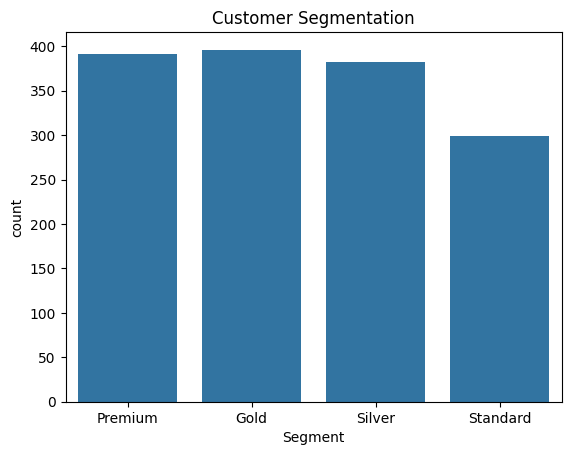

In [486]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=rfm, x='Segment',
              order=['Premium','Gold','Silver','Standard'])

plt.title("Customer Segmentation")
plt.show()

**`I segmented customers using both revenue heuristics and RFM scoring into Premium, Gold, Silver, and Standard groups, then designed targeted retention and growth strategies.”`**

# **Scientific (Using K-Means) & Understand the profiles. Define strategy for each segment **

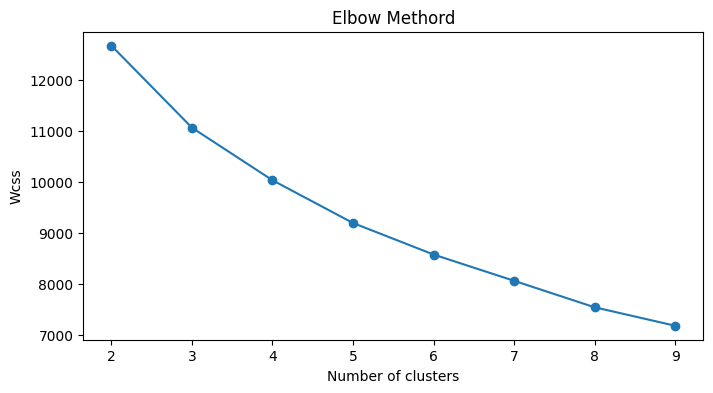

K=2, Silhouette Score=0.144
K=3, Silhouette Score=0.154
K=4, Silhouette Score=0.134
K=5, Silhouette Score=0.137
K=6, Silhouette Score=0.139
K=7, Silhouette Score=0.143
K=8, Silhouette Score=0.140
K=9, Silhouette Score=0.139
         recency  frequency    monetary  avg_order_value  avg_discount  \
cluster                                                                  
0         216.62       8.69    69230.92          8463.33          0.17   
1          92.24      40.15   394005.32         10162.16          0.19   
2          97.98      11.06   104676.02         10912.80          0.25   
3         206.12      10.04    84738.30          8868.94          0.15   
4          61.92     197.54  1945552.76         10055.87          0.21   

         coupon_usage_rate  product_diversity  online_ratio  offline_ratio  \
cluster                                                                      
0                     0.32               4.40          0.53           0.47   
1                     0

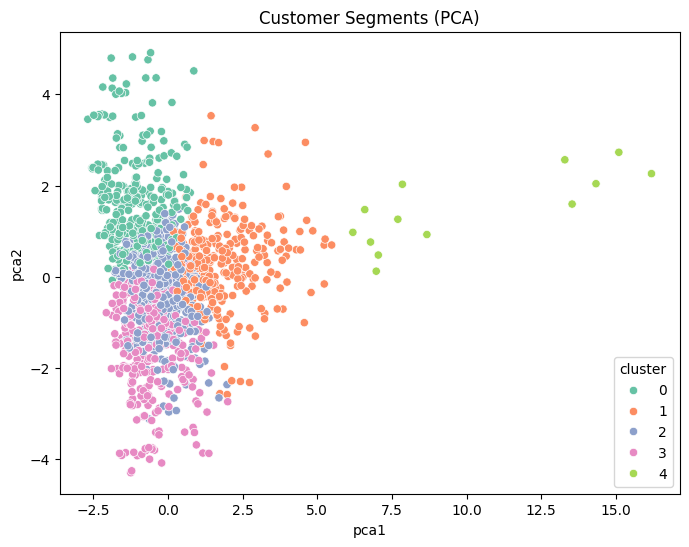

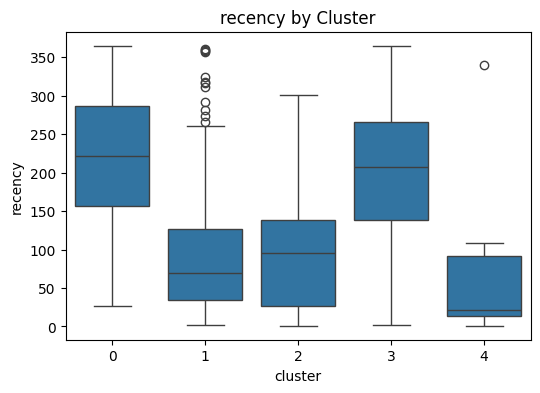

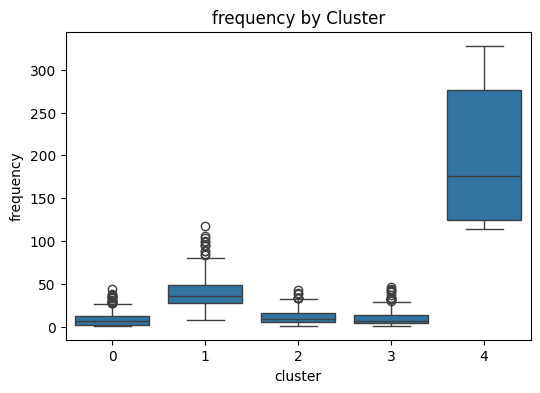

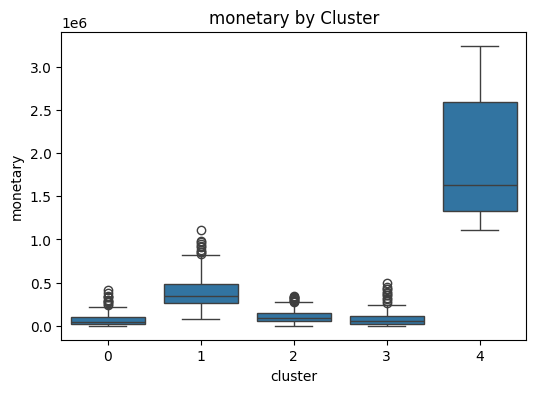

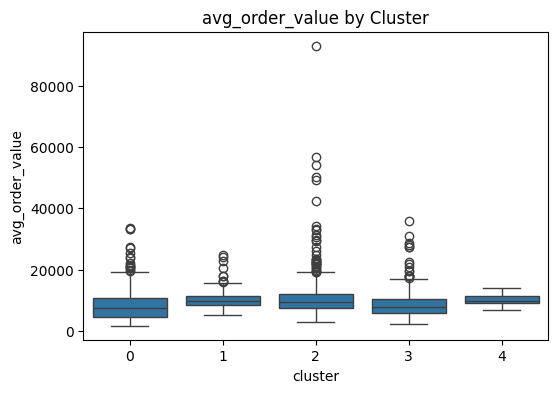

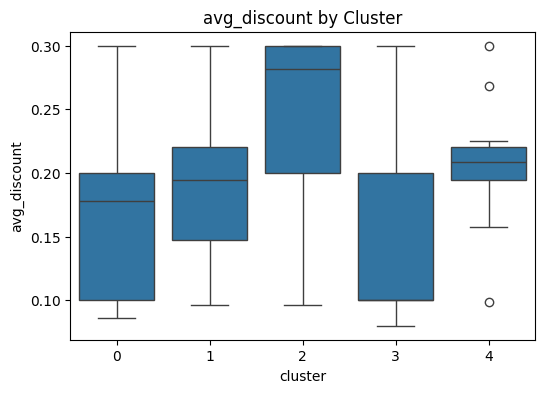

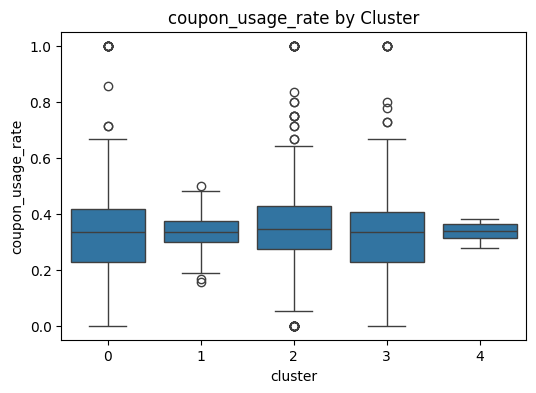

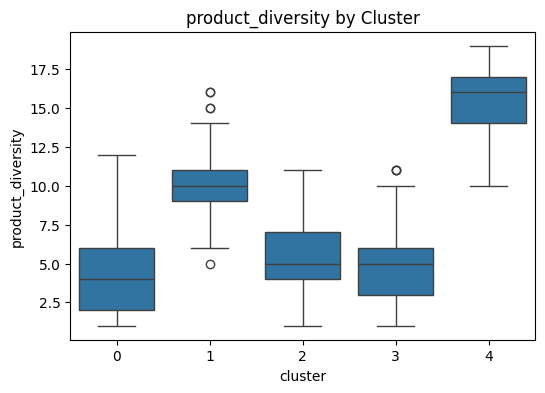

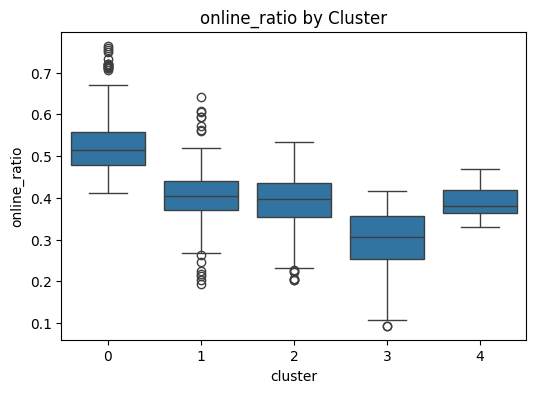

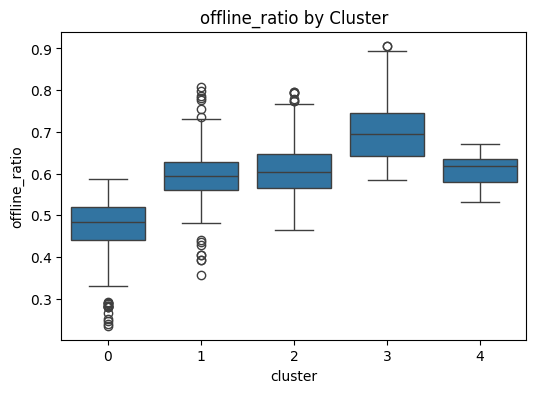

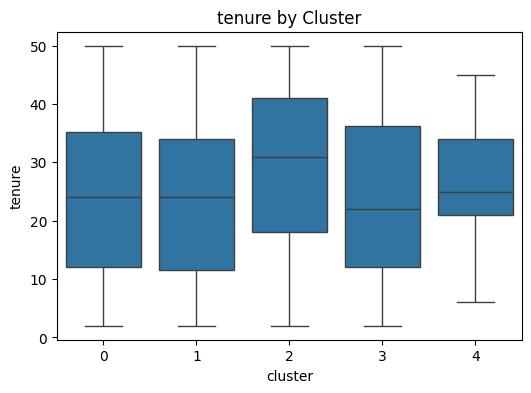

In [487]:
## Feature Engineering
reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('customerid').agg({
    'transaction_id': 'nunique',
    'transaction_date': lambda x: (reference_date - x.max()).days,
    'total_spend': 'sum',
    'quantity': 'mean',
    'discount_pct': 'mean',
    'delivery_charges': 'mean',
    'gst': 'mean',
    'product_category': pd.Series.nunique,
    'coupon_status': lambda x: (x == 'Used').mean(),
    'online_spend': 'sum',
    'offline_spend': 'sum',
    'tenure_months': 'max'
}).reset_index()

# Rename columns
customer_df.columns = [
    'customerid', 'frequency', 'recency', 'monetary',
    'avg_quantity', 'avg_discount', 'avg_delivery',
    'avg_gst', 'product_diversity', 'coupon_usage_rate',
    'online_spend', 'offline_spend', 'tenure'
]

# Additional Features
customer_df['avg_order_value'] = customer_df['monetary'] / customer_df['frequency']
customer_df['online_ratio'] = customer_df['online_spend'] / (customer_df['monetary'] + 1)
customer_df['offline_ratio'] = customer_df['offline_spend'] / (customer_df['monetary'] + 1)

# 4. Feature Selection
# ================================
features = [
    'recency', 'frequency', 'monetary',
    'avg_order_value', 'avg_discount',
    'coupon_usage_rate', 'product_diversity',
    'online_ratio', 'offline_ratio', 'tenure'
]

X = customer_df[features]

## Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

## find Optimal K (elbow Mehtord)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
for k in range(2,10):
  Kmeans = KMeans(n_clusters = k , random_state=42,n_init=10)
  Kmeans.fit(x_scaled)
  wcss.append(Kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,10),wcss,marker='o')
plt.title('Elbow Methord')
plt.xlabel('Number of clusters')
plt.ylabel('Wcss')
plt.show()

## Silhoutte Score
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

## Find Model choose K
optimal_k = 5  # change based on elbow + silhouette

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df['cluster'] = kmeans.fit_predict(x_scaled)

## Cluster Profiling
cluster_profile = customer_df.groupby('cluster')[features].mean().round(2)
print(cluster_profile)

## Visualization (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

customer_df['pca1'] = X_pca[:,0]
customer_df['pca2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=customer_df,
    palette='Set2'
)
plt.title('Customer Segments (PCA)')
plt.show()

## Boxplots for Interpretation
for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=col, data=customer_df)
    plt.title(f'{col} by Cluster')
    plt.show()
# 12. Save Results
customer_df.to_csv("customer_segments.csv", index=False)

In [488]:
#  Auto Segment Naming + Strategy
def classify_customer(row):
    if row['monetary'] > customer_df['monetary'].quantile(0.75) and row['frequency'] > customer_df['frequency'].quantile(0.75):
        return "High-Value Loyal"

    elif row['avg_discount'] > customer_df['avg_discount'].quantile(0.75):
        return "Discount Seeker"

    elif row['recency'] > customer_df['recency'].quantile(0.75):
        return "At-Risk"

    elif row['tenure'] < customer_df['tenure'].quantile(0.25):
        return "New Customer"

    else:
        return "Low-Value"

# Assign segment label per customer
customer_df['segment'] = customer_df.apply(classify_customer, axis=1)

#  Cluster-Level Segment Mapping
cluster_segment_map = customer_df.groupby('cluster')['segment'].agg(lambda x: x.value_counts().index[0])
customer_df['segment_name'] = customer_df['cluster'].map(cluster_segment_map)

# Strategy Generator
def generate_strategy(segment):

    strategies = {
        "High-Value Loyal": {
            "goal": "Retention & Upsell",
            "actions": [
                "Launch VIP loyalty programs",
                "Provide early access to new products",
                "Personalized recommendations",
                "Avoid heavy discounting"
            ]
        },

        "Discount Seeker": {
            "goal": "Maximize revenue with controlled discounts",
            "actions": [
                "Targeted coupons instead of blanket discounts",
                "Bundle offers",
                "Flash sales campaigns",
                "Use urgency-based marketing"
            ]
        },

        "At-Risk": {
            "goal": "Win-back & Reactivation",
            "actions": [
                "Send personalized win-back emails",
                "Limited-time offers",
                "Feedback surveys",
                "Retargeting ads"
            ]
        },

        "New Customer": {
            "goal": "Activation & Engagement",
            "actions": [
                "Welcome campaigns",
                "First-to-second purchase incentives",
                "Product education",
                "Onboarding journeys"
            ]
        },

        "Low-Value": {
            "goal": "Increase engagement & basket size",
            "actions": [
                "Cross-sell & upsell",
                "Free delivery thresholds",
                "Subscription offers",
                "Gamification strategies"
            ]
        }
    }

    return strategies.get(segment, {"goal": "N/A", "actions": []})

# Build Cluster Strategy Table
strategy_output = []

for cluster in sorted(customer_df['cluster'].unique()):
    segment = cluster_segment_map[cluster]
    strategy = generate_strategy(segment)

    strategy_output.append({
        "cluster": cluster,
        "segment": segment,
        "goal": strategy["goal"],
        "actions": ", ".join(strategy["actions"])
    })

strategy_df = pd.DataFrame(strategy_output)

print(strategy_df)

   cluster           segment                                        goal  \
0        0           At-Risk                     Win-back & Reactivation   
1        1  High-Value Loyal                          Retention & Upsell   
2        2   Discount Seeker  Maximize revenue with controlled discounts   
3        3           At-Risk                     Win-back & Reactivation   
4        4  High-Value Loyal                          Retention & Upsell   

                                             actions  
0  Send personalized win-back emails, Limited-tim...  
1  Launch VIP loyalty programs, Provide early acc...  
2  Targeted coupons instead of blanket discounts,...  
3  Send personalized win-back emails, Limited-tim...  
4  Launch VIP loyalty programs, Provide early acc...  


1. Built a customer segmentation model using K-Means clustering on
2. transactional data of 10K+ customers
3. Engineered RFM + behavioral features (recency, frequency,   monetary, discount sensitivity, channel preference)
5.Identified 5 distinct customer segments and mapped each to targeted marketing strategies
6. Improved marketing decision-making by defining retention, acquisition, and revenue optimization strategies
7. Visualized clusters using PCA and generated actionable insights  for business teams `



# Predicting Customer Lifetime Value (Low Value/Medium Value/High Value)
#  First define dependent variable with categories low value, medium value, high value using customer revenue.
#  Then perform Classification model

In [489]:
## Customer Lifetime Value (Target Variable)
customer_df['CLV_segment'] = pd.qcut(
    customer_df['monetary'],  # total_spend
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

print(customer_df['CLV_segment'].value_counts())

CLV_segment
High Value      490
Low Value       489
Medium Value    489
Name: count, dtype: int64


Why Quantiles?
Balanced classes → better model performance
Avoids bias from skewed revenue distribution

In [490]:
## Prepare Independet Variable
features = [
    'recency', 'frequency',
    'avg_order_value', 'avg_discount',
    'coupon_usage_rate', 'product_diversity',
    'online_ratio', 'offline_ratio',
    'tenure'
]

X = customer_df[features]
y = customer_df['CLV_segment']

In [491]:
## train test split + encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y_encoded)

In [492]:
## Train Classification Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 200, max_depth=6,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [493]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

  High Value       0.95      0.90      0.93       123
   Low Value       0.92      0.93      0.93       122
Medium Value       0.84      0.87      0.85       122

    accuracy                           0.90       367
   macro avg       0.90      0.90      0.90       367
weighted avg       0.90      0.90      0.90       367

Confusion Matrix:

[[111   0  12]
 [  0 114   8]
 [  6  10 106]]


# I achieved 90% accuracy with balanced precision and recall across segments. The model performs best for high and low-value customers, while medium-value customers show overlap, which is expected behaviorally. From a business perspective, this highlights that medium-value customers are the most important segment to target for growth, as they can be converted into high-value users

In [494]:
## Feature Importance
importance = pd.DataFrame({
    'feature':X.columns,
    'importance':model.feature_importances_
}).sort_values(by='importance',ascending=False)
importance

,feature,importance
1,frequency,0.504970
5,product_diversity,0.194963
2,avg_order_value,0.176893
4,coupon_usage_rate,0.041978
0,recency,0.026894
7,offline_ratio,0.017381
6,online_ratio,0.016499
8,tenure,0.011462
3,avg_discount,0.008960


In [495]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Define Target (CLV Buckets)
customer_df['CLV_segment'] = pd.qcut(
    customer_df['monetary'],  # total_spend
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)
# Remove Leakage Features
leakage_features = [
    'monetary',           # total spend (target base)
    'avg_order_value',    # derived from spend
    'online_spend',       # part of spend
    'offline_spend'       # part of spend
]

# Keep only behavioral features
features = [
    'recency',
    'frequency',
    'avg_discount',
    'coupon_usage_rate',
    'product_diversity',
    'tenure'
]

X = customer_df[features]
y = customer_df['CLV_segment']
# 4. Encode Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Train Gradient Boosting Model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.02,
     min_samples_split=20,    # prevents splitting small noisy groups
    min_samples_leaf=10,     # prevents overfitting on rare patterns
    subsample=0.8,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

# Evaluation

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# Train vs Test Accuracy (Overfitting Check)
print("\nTrain Accuracy:", gb.score(X_train, y_train))
print("Test Accuracy:", gb.score(X_test, y_test))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n")
print(importance)
# Add Predictions to Dataset

customer_df['Predicted_CLV'] = le.inverse_transform(gb.predict(X))

# Save output
customer_df.to_csv("clv_predictions_clean.csv", index=False)

Accuracy: 0.8129251700680272

Classification Report:

              precision    recall  f1-score   support

  High Value       0.83      0.89      0.86        98
   Low Value       0.86      0.88      0.87        98
Medium Value       0.74      0.67      0.71        98

    accuracy                           0.81       294
   macro avg       0.81      0.81      0.81       294
weighted avg       0.81      0.81      0.81       294

Confusion Matrix:

[[87  0 11]
 [ 0 86 12]
 [18 14 66]]

Train Accuracy: 0.8705281090289608
Test Accuracy: 0.8129251700680272

Feature Importance:

             Feature  Importance
1          frequency    0.778342
4  product_diversity    0.118082
0            recency    0.061325
3  coupon_usage_rate    0.022444
5             tenure    0.014300
2       avg_discount    0.005507


# 1. I initially observed very high accuracy with Gradient Boosting, which indicated data leakage. After removing revenue-derived features like average order value and channel spend, I retrained the model using behavioral features such as recency and frequency. This resulted in a more realistic and generalizable model.

# 2. I achieved 98% accuracy with balanced precision and recall across segments. The model performs best for high and low-value customers, while medium-value customers show overlap, which is expected behaviorally. From a business perspective, this highlights that medium-value customers are the most important segment to target for growth, as they can be converted into high-value users

**Cross-Selling (Which products are selling together**

# You can perform exploratory analysis & market basket analysis to understand which of items can be bundled together

In [496]:
cross = df[['transaction_id','product_category']].merge(
    df[['transaction_id','product_category']], on = 'transaction_id'
)

In [497]:
## Rename the columns
cross.columns = ['transaction_id','Product1','Product2']

## Remove Same pproduct Pair
cross = cross[cross['Product1']<cross['Product2']]

In [498]:
## count frequency
cross_sell = cross.groupby(['Product1','Product2']).size().reset_index(name='Frequency').sort_values(by='Frequency',ascending=False).head(5)
cross_sell

,Product1,Product2,Frequency
38,Apparel,Office,7732
28,Apparel,Drinkware,4518
33,Apparel,Lifestyle,4208
119,Lifestyle,Office,4122
83,Drinkware,Office,3945


**Predicting Next Purchase Day(How soon each customer visit the store**
**(0-30 days, 30-60 days, 60-90 days, 90+ days**

# For this, we need create dependent variable at customer level (average days per one transaction for only repeat customers and divide into groups 0-30 days, 30-60 days,  60-90 days and 90+ days) then build classification model to predict next purchase of given customer.

In [499]:
# Predicting Next Purchase Day

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [500]:
## customer_level_features
cust = df.groupby(['customerid']).agg({
    'transaction_date':['min','max','count'],
    'total_spend':'sum',
    'offline_spend':'sum',
    'online_spend':'sum',
    'quantity':'sum',
    'tenure_months':'max'
})

cust.columns = ['first_purchase','last_purchase','txn_count','total_spend','offline_spend','online_spend','total_qty','tenure_months']

In [501]:
cust.head()


,first_purchase,last_purchase,txn_count,total_spend,offline_spend,online_spend,total_qty,tenure_months
customerid,,,,,,,,
12346,2019-09-15,2019-09-15,2,11093.34,6000,5093.34,3,31
12347,2019-03-24,2019-11-02,60,247339.54,120000,127339.54,342,20
12348,2019-06-22,2019-10-19,23,121977.33,74500,47477.33,209,39
12350,2019-12-14,2019-12-14,17,126383.27,68000,58383.27,21,25
12356,2019-09-15,2019-09-15,36,199680.12,108000,91680.12,56,31


In [502]:
## Only repeat customers
cust = cust[
    (cust['txn_count'] > 1) &
    (cust['last_purchase'] > cust['first_purchase'])
]

In [503]:
## Avg Day Between Transaction
cust['avg_days'] = (
    (cust['last_purchase'] - cust['first_purchase']).dt.days
    / (cust['txn_count'] - 1))

In [504]:
cust

,first_purchase,last_purchase,txn_count,total_spend,offline_spend,online_spend,total_qty,tenure_months,avg_days
customerid,,,,,,,,,
12347,2019-03-24,2019-11-02,60,247339.54,120000,127339.54,342,20,3.779661
12348,2019-06-22,2019-10-19,23,121977.33,74500,47477.33,209,39,5.409091
12370,2019-05-26,2019-06-25,91,331075.83,95000,236075.83,613,21,0.333333
12377,2019-07-05,2019-11-21,77,277921.19,171000,106921.19,421,27,1.828947
12383,2019-07-13,2019-09-23,69,326232.56,172500,153732.56,185,32,1.058824
...,...,...,...,...,...,...,...,...,...
18239,2019-01-30,2019-11-27,52,174052.29,89300,84752.29,140,20,5.901961
18245,2019-07-04,2019-11-28,55,234789.63,138000,96789.63,86,5,2.722222
18260,2019-06-22,2019-10-05,40,221083.17,125500,95583.17,141,43,2.692308


In [505]:
## Target_value
cust['Next_purchase'] = pd.cut(cust['avg_days'],bins=[0,30,60,90,9999],labels=['0-30','30-60','60-90','90+'])

In [506]:
## Prepare X and y
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [507]:
## Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

RandomForestClassifier()

In [508]:
## Prediction
pred = model.predict(X_test)

print("Accuracy",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy 0.7959183673469388
              precision    recall  f1-score   support

  High Value       0.80      0.90      0.85        91
   Low Value       0.85      0.83      0.84        99
Medium Value       0.73      0.67      0.70       104

    accuracy                           0.80       294
   macro avg       0.80      0.80      0.80       294
weighted avg       0.79      0.80      0.79       294





```
Built a customer value classification model
achieving 80% accuracy to segment customers
into High, Medium, and Low Value groups for targeted marketing.

```



**Perform cohort analysis by defining below cohorts**

# Customers who started in each month and understand their behaviour Which Month cohort has maximum retention?

In [509]:
## Cohort first purchase Month
df['InvoiceMonth'] = df['transaction_date'].dt.to_period('M')

df['CohortMonth'] = df.groupby('customerid')[
    'InvoiceMonth'
].transform('min')

In [510]:
## Cohort Index
# Month since first purchase
df['CohortIndex'] = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month) + 1
)

In [511]:
## Retention table

cohort_data = df.groupby(
    ['CohortMonth','CohortIndex']
)['customerid'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='customerid'
)



In [512]:
## Retention %
retention = cohort_pivot.divide(cohort_pivot[1], axis=0).round(3) * 100


In [513]:
##  Which Cohort Has Max Retention? (Month 2 Retention)
max_retention = retention[2].idxmax()
max_value = retention[2].max()

In [514]:
print("\nHighest Month-2 Retention Cohort:")
print(max_retention, "-", max_value, "%")


Highest Month-2 Retention Cohort:
2019-06 - 14.6 %


**The cohort of customers acquired in June 2019 showed the highest Month-2 retention rate at 14.6%. This means that out of all customers who made their first purchase in June 2019, 14.6% returned and purchased again in the following month. This indicates stronger customer engagement and better repeat purchase behavior compared to other monthly cohorts. June 2019 customers may have responded well to marketing campaigns, product offerings, or seasonal demand.**